# Notebook 4: User Behavior Profiles

This notebook focuses on **differences between users** rather than differences between queries.

The main idea is that not all participants use AI in the same way. Even if two users submit the same number of queries, they may rely on the system for very different purposes. Some may mostly ask for information, some may use AI to support decisions, and others may use it to solve concrete problems.

We are doing this analysis for three reasons:

1. **User heterogeneity**: overall averages can hide meaningful differences between participants.
2. **Behavioral profiling**: participants may naturally group into recurring usage styles.
3. **HCI relevance**: in human-AI interaction research, identifying user profiles helps explain how different people appropriate the same system in different ways.

This notebook asks:

- Do some users mostly ask one type of query?
- Are there recognizable user groups based on their query behavior?
- Can we describe these groups as profiles such as **Information Seekers**, **Decision Makers**, and **Problem Solvers**?

## 1. Import packages

We import packages for data handling, plotting, and clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

## 2. Load the cleaned dataset

This notebook uses the cleaned file and focuses mainly on:

- `participant_no`
- `final_type`
- `final_task`
- `final_goal`

The main clustering analysis below starts with `final_type`, because information type is a simple and interpretable first view of user behavior.

In [2]:
file_path = '../Reconciled_Final.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (2115, 6)


,participant_no,week_no,query,final_type,final_task,final_goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
4,102,Week 1,vegan foods to eat that help lose weight,ideas/options,option seeking,plan


## 3. Basic checks

Before profiling users, we confirm that participant IDs and final labels are available.

Why this matters:
- User-level analysis depends on correctly identifying which queries belong to which participant.
- Missing labels can distort the profile of a participant.

In [3]:
required_cols = ['participant_no', 'final_type', 'final_task', 'final_goal']
missing_required = [c for c in required_cols if c not in df.columns]
print('Missing required columns:', missing_required)

df[required_cols].isna().sum()

Missing required columns: []


participant_no    0
final_type        0
final_task        0
final_goal        0
dtype: int64

In [4]:
profile_df = df.dropna(subset=['participant_no', 'final_type']).copy()
print('Rows kept for user profile analysis:', len(profile_df))
print('Unique participants:', profile_df['participant_no'].nunique())

Rows kept for user profile analysis: 2115
Unique participants: 23


## 4. Query volume by participant

Before clustering users, it is useful to know how many queries each participant contributed.

Why this matters:
- A participant with only one or two queries may not have a stable behavior profile.
- Heavy users may show more reliable behavioral patterns.
- This helps us interpret clusters more carefully.

In [5]:
queries_per_user = profile_df.groupby('participant_no').size().reset_index(name='n_queries')
queries_per_user = queries_per_user.sort_values('n_queries', ascending=False)
queries_per_user.head(20)

,participant_no,n_queries
4,109,253
18,130,233
0,102,201
6,112,179
7,113,147
16,127,142
8,114,115
13,121,87
11,119,87
17,128,80


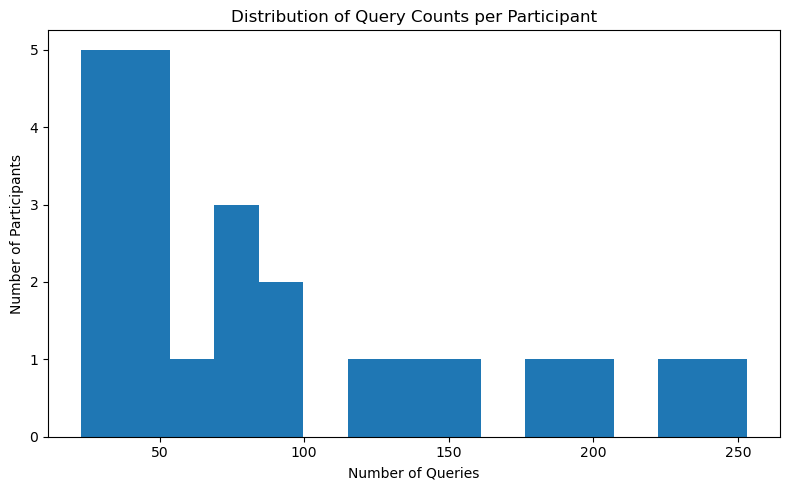

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(queries_per_user['n_queries'], bins=15)
plt.title('Distribution of Query Counts per Participant')
plt.xlabel('Number of Queries')
plt.ylabel('Number of Participants')
plt.tight_layout()
plt.show()

## 5. Type distribution per user

This is the core input for the first user-profile analysis.

We compute, for each participant, the proportion of their queries that fall into each `final_type` category.

Why this matters:
- Raw counts are affected by how many queries a person submitted.
- Row-normalized proportions let us compare users fairly.
- This produces a compact behavioral signature for each participant.

In [7]:
user_type = pd.crosstab(
    profile_df['participant_no'],
    profile_df['final_type'],
    normalize='index'
)

user_type.head(10)

final_type,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility
participant_no,,,,,,,,,,,,,,,,,,,,
102,0.034826,0.029851,0.248756,0.000000,0.014925,0.004975,0.000000,0.0,0.218905,0.034826,0.004975,0.139303,0.044776,0.039801,0.0,0.104478,0.004975,0.0,0.0,0.074627
103,0.000000,0.000000,0.128205,0.000000,0.102564,0.000000,0.000000,0.0,0.769231,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000
107,0.054054,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.351351,0.000000,0.054054,0.135135,0.270270,0.000000,0.0,0.135135,0.000000,0.0,0.0,0.000000
108,0.000000,0.040816,0.122449,0.040816,0.000000,0.000000,0.000000,0.0,0.204082,0.000000,0.265306,0.000000,0.020408,0.000000,0.0,0.040816,0.000000,0.0,0.0,0.265306
109,0.000000,0.003953,0.126482,0.000000,0.063241,0.000000,0.019763,0.0,0.320158,0.023715,0.213439,0.027668,0.023715,0.031621,0.0,0.114625,0.000000,0.0,0.0,0.031621
111,0.047619,0.000000,0.047619,0.000000,0.000000,0.000000,0.000000,0.0,0.452381,0.071429,0.000000,0.047619,0.023810,0.000000,0.0,0.261905,0.000000,0.0,0.0,0.047619
112,0.000000,0.000000,0.156425,0.000000,0.111732,0.000000,0.000000,0.0,0.625698,0.016760,0.016760,0.016760,0.000000,0.000000,0.0,0.016760,0.000000,0.0,0.0,0.039106
113,0.000000,0.006803,0.156463,0.000000,0.054422,0.000000,0.000000,0.0,0.721088,0.000000,0.000000,0.047619,0.000000,0.000000,0.0,0.013605,0.000000,0.0,0.0,0.000000
114,0.000000,0.017391,0.121739,0.000000,0.330435,0.000000,0.000000,0.0,0.460870,0.000000,0.026087,0.026087,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.017391


## 6. Most dominant type per user

Before clustering, it is useful to inspect the dominant information type for each participant.

Why this matters:
- It provides a very interpretable first-pass user summary.
- It helps us see whether some users are strongly specialized or more balanced across types.

In [8]:
dominant_type = user_type.idxmax(axis=1).reset_index(name='dominant_type')
dominant_strength = user_type.max(axis=1).reset_index(name='dominant_type_share')

dominant_summary = dominant_type.merge(dominant_strength, on='participant_no')
dominant_summary.head(20)

,participant_no,dominant_type,dominant_type_share
0,102,factual,0.248756
1,103,ideas/options,0.769231
2,107,ideas/options,0.351351
3,108,na,0.265306
4,109,ideas/options,0.320158
5,111,ideas/options,0.452381
6,112,ideas/options,0.625698
7,113,ideas/options,0.721088
8,114,ideas/options,0.460870
9,116,ideas/options,0.514286


In [9]:
dominant_summary['dominant_type'].value_counts()

dominant_type
ideas/options    16
factual           4
na                2
outcome           1
Name: count, dtype: int64

## 7. Cluster users based on type distribution

Now we use clustering to detect groups of participants with similar type distributions.

Why this matters:
- Clustering can reveal recurring user styles without us having to define them manually in advance.
- This is useful in HCI because different forms of system use may correspond to different mental models or needs.
- Here we start with `KMeans(n_clusters=3)` to match the three example profiles you proposed.

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(user_type)

user_profiles = user_type.copy()
user_profiles['cluster'] = clusters
user_profiles.head(10)

final_type,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility,cluster
participant_no,,,,,,,,,,,,,,,,,,,,,
102,0.034826,0.029851,0.248756,0.000000,0.014925,0.004975,0.000000,0.0,0.218905,0.034826,0.004975,0.139303,0.044776,0.039801,0.0,0.104478,0.004975,0.0,0.0,0.074627,2
103,0.000000,0.000000,0.128205,0.000000,0.102564,0.000000,0.000000,0.0,0.769231,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,1
107,0.054054,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.351351,0.000000,0.054054,0.135135,0.270270,0.000000,0.0,0.135135,0.000000,0.0,0.0,0.000000,0
108,0.000000,0.040816,0.122449,0.040816,0.000000,0.000000,0.000000,0.0,0.204082,0.000000,0.265306,0.000000,0.020408,0.000000,0.0,0.040816,0.000000,0.0,0.0,0.265306,2
109,0.000000,0.003953,0.126482,0.000000,0.063241,0.000000,0.019763,0.0,0.320158,0.023715,0.213439,0.027668,0.023715,0.031621,0.0,0.114625,0.000000,0.0,0.0,0.031621,2
111,0.047619,0.000000,0.047619,0.000000,0.000000,0.000000,0.000000,0.0,0.452381,0.071429,0.000000,0.047619,0.023810,0.000000,0.0,0.261905,0.000000,0.0,0.0,0.047619,0
112,0.000000,0.000000,0.156425,0.000000,0.111732,0.000000,0.000000,0.0,0.625698,0.016760,0.016760,0.016760,0.000000,0.000000,0.0,0.016760,0.000000,0.0,0.0,0.039106,1
113,0.000000,0.006803,0.156463,0.000000,0.054422,0.000000,0.000000,0.0,0.721088,0.000000,0.000000,0.047619,0.000000,0.000000,0.0,0.013605,0.000000,0.0,0.0,0.000000,1
114,0.000000,0.017391,0.121739,0.000000,0.330435,0.000000,0.000000,0.0,0.460870,0.000000,0.026087,0.026087,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.017391,1


## 8. Cluster centers

To interpret the clusters, we inspect the cluster centers.

Why this matters:
- Each center shows the average type distribution for users in that cluster.
- This helps us understand what kind of user each cluster represents.

In [11]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=user_type.columns)
cluster_centers.index.name = 'cluster'
cluster_centers

final_type,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility
cluster,,,,,,,,,,,,,,,,,,,,
0,0.033634,0.05000,0.016197,0.000000e+00,0.036803,0.000000,0.075031,0.000000,0.339222,0.031806,0.017085,0.061768,0.084234,0.096919,0.000000e+00,0.144324,0.000000,0.000000,0.000000e+00,0.012978
1,0.009579,0.05205,0.125599,-2.168404e-19,0.059484,0.000000,0.006127,0.001225,0.606581,0.003312,0.066999,0.017332,0.001916,0.004167,-8.673617e-19,0.033780,0.000000,0.000000,1.225490e-03,0.010623
2,0.009057,0.01066,0.244840,5.830904e-03,0.026677,0.000711,0.002823,0.008163,0.244936,0.008363,0.208003,0.023853,0.012700,0.019999,1.306122e-02,0.070966,0.000711,0.018367,1.084202e-19,0.070279


## 9. Assign human-readable profile names

To make the clusters easier to discuss, we assign descriptive names.

At this stage, the labels are interpretive and should be checked against the actual cluster centers. A common approach is:

- cluster dominated by information-seeking types → **Information Seekers**
- cluster dominated by recommendation or choice-oriented types → **Decision Makers**
- cluster dominated by procedural or troubleshooting types → **Problem Solvers**

Because actual label names depend on your dataset, the code below first shows each cluster's dominant type.

In [12]:
cluster_dominant_type = cluster_centers.idxmax(axis=1).reset_index(name='dominant_type')
cluster_dominant_type

,cluster,dominant_type
0,0,ideas/options
1,1,ideas/options
2,2,ideas/options


After inspecting the dominant types, update the mapping below if needed. The default names here are placeholders for interpretation.

In [13]:
cluster_name_map = {
    0: 'Information Seekers',
    1: 'Decision Makers',
    2: 'Problem Solvers'
}

user_profiles['profile_name'] = user_profiles['cluster'].map(cluster_name_map)
user_profiles.head(10)

final_type,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility,cluster,profile_name
participant_no,,,,,,,,,,,,,,,,,,,,,,
102,0.034826,0.029851,0.248756,0.000000,0.014925,0.004975,0.000000,0.0,0.218905,0.034826,0.004975,0.139303,0.044776,0.039801,0.0,0.104478,0.004975,0.0,0.0,0.074627,2,Problem Solvers
103,0.000000,0.000000,0.128205,0.000000,0.102564,0.000000,0.000000,0.0,0.769231,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,1,Decision Makers
107,0.054054,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.351351,0.000000,0.054054,0.135135,0.270270,0.000000,0.0,0.135135,0.000000,0.0,0.0,0.000000,0,Information Seekers
108,0.000000,0.040816,0.122449,0.040816,0.000000,0.000000,0.000000,0.0,0.204082,0.000000,0.265306,0.000000,0.020408,0.000000,0.0,0.040816,0.000000,0.0,0.0,0.265306,2,Problem Solvers
109,0.000000,0.003953,0.126482,0.000000,0.063241,0.000000,0.019763,0.0,0.320158,0.023715,0.213439,0.027668,0.023715,0.031621,0.0,0.114625,0.000000,0.0,0.0,0.031621,2,Problem Solvers
111,0.047619,0.000000,0.047619,0.000000,0.000000,0.000000,0.000000,0.0,0.452381,0.071429,0.000000,0.047619,0.023810,0.000000,0.0,0.261905,0.000000,0.0,0.0,0.047619,0,Information Seekers
112,0.000000,0.000000,0.156425,0.000000,0.111732,0.000000,0.000000,0.0,0.625698,0.016760,0.016760,0.016760,0.000000,0.000000,0.0,0.016760,0.000000,0.0,0.0,0.039106,1,Decision Makers
113,0.000000,0.006803,0.156463,0.000000,0.054422,0.000000,0.000000,0.0,0.721088,0.000000,0.000000,0.047619,0.000000,0.000000,0.0,0.013605,0.000000,0.0,0.0,0.000000,1,Decision Makers
114,0.000000,0.017391,0.121739,0.000000,0.330435,0.000000,0.000000,0.0,0.460870,0.000000,0.026087,0.026087,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.017391,1,Decision Makers


## 10. How many users fall into each profile?

This gives a simple summary of how common each user profile is.

In [14]:
profile_counts = user_profiles['profile_name'].value_counts().reset_index()
profile_counts.columns = ['profile_name', 'n_users']
profile_counts

,profile_name,n_users
0,Decision Makers,12
1,Problem Solvers,7
2,Information Seekers,4


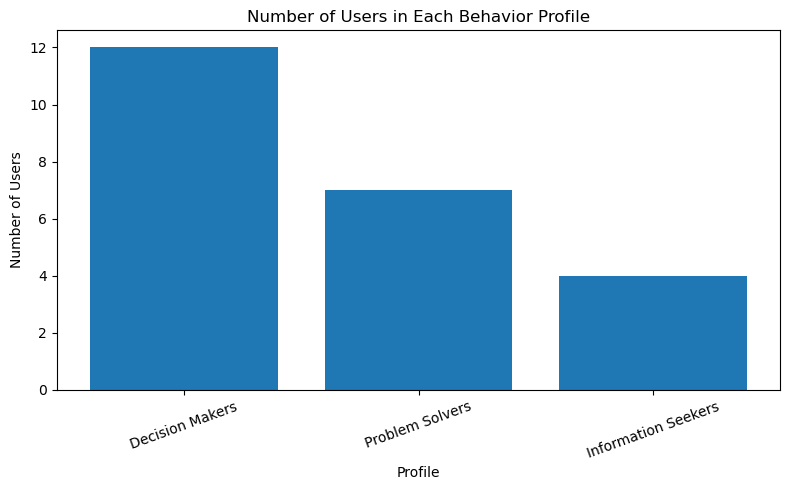

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(profile_counts['profile_name'], profile_counts['n_users'])
plt.title('Number of Users in Each Behavior Profile')
plt.xlabel('Profile')
plt.ylabel('Number of Users')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 11. Average type distribution within each profile

Now we summarize what each profile looks like.

Why this matters:
- This shows the behavioral signature of each profile.
- It lets us compare the profiles side by side.

In [16]:
profile_type_summary = user_profiles.groupby('profile_name')[user_type.columns.tolist()].mean()
profile_type_summary

final_type,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility
profile_name,,,,,,,,,,,,,,,,,,,,
Decision Makers,0.009579,0.05205,0.125599,0.000000,0.059484,0.000000,0.006127,0.001225,0.606581,0.003312,0.066999,0.017332,0.001916,0.004167,0.000000,0.033780,0.000000,0.000000,0.001225,0.010623
Information Seekers,0.033634,0.05000,0.016197,0.000000,0.036803,0.000000,0.075031,0.000000,0.339222,0.031806,0.017085,0.061768,0.084234,0.096919,0.000000,0.144324,0.000000,0.000000,0.000000,0.012978
Problem Solvers,0.009057,0.01066,0.244840,0.005831,0.026677,0.000711,0.002823,0.008163,0.244936,0.008363,0.208003,0.023853,0.012700,0.019999,0.013061,0.070966,0.000711,0.018367,0.000000,0.070279


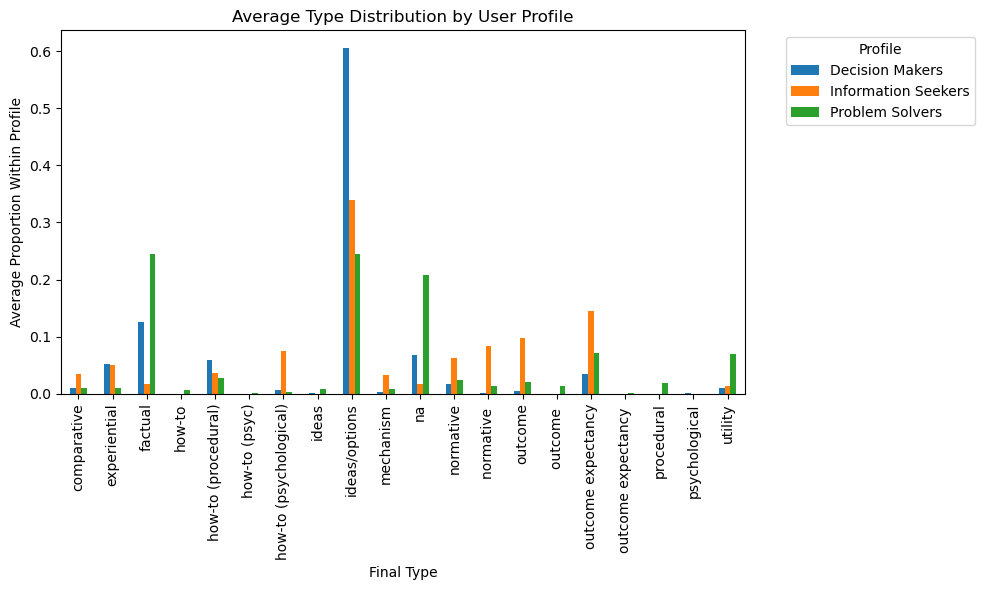

In [17]:
profile_type_summary.T.plot(kind='bar', figsize=(10, 6))
plt.title('Average Type Distribution by User Profile')
plt.xlabel('Final Type')
plt.ylabel('Average Proportion Within Profile')
plt.legend(title='Profile', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 12. Add task and goal summaries by profile

Although clustering is based on `final_type`, it is useful to see whether the resulting user groups also differ in task and goal.

Why this matters:
- This helps validate whether the profiles capture broader behavioral differences.
- It also makes the profiles richer and more meaningful for interpretation.

In [18]:
participant_profile_map = user_profiles[['cluster', 'profile_name']].reset_index().rename(columns={'participant_no': 'participant_no'})
merged = df.merge(participant_profile_map[['participant_no', 'profile_name']], on='participant_no', how='left')

profile_task = pd.crosstab(merged['profile_name'], merged['final_task'], normalize='index')
profile_goal = pd.crosstab(merged['profile_name'], merged['final_goal'], normalize='index')

print('Task distribution by profile')
display(profile_task.round(3))

print('Goal distribution by profile')
display(profile_goal.round(3))

Task distribution by profile


final_task,barrier,barrier,barrier management,evaluate,evalute,learn,logistics,na,option seeking,perform
profile_name,,,,,,,,,,
Decision Makers,0.004,0.004,0.032,0.046,0.000,0.255,0.037,0.042,0.572,0.008
Information Seekers,0.031,0.000,0.086,0.102,0.003,0.521,0.000,0.008,0.241,0.008
Problem Solvers,0.000,0.000,0.009,0.070,0.000,0.340,0.052,0.228,0.263,0.039


Goal distribution by profile


final_goal,action,decision,decision making,motivational,motivational,motivational reasoning,na,plan
profile_name,,,,,,,,
Decision Makers,0.055,0.005,0.134,0.013,0.000,0.059,0.039,0.695
Information Seekers,0.013,0.008,0.097,0.081,0.003,0.225,0.008,0.565
Problem Solvers,0.077,0.000,0.126,0.024,0.007,0.041,0.207,0.518


## 13. Inspect example users in each profile

To ground the clusters in actual participant behavior, we inspect a few users from each profile.

Why this matters:
- Clusters are easier to trust when we can connect them back to real examples.
- This is useful for qualitative interpretation and reporting.

In [19]:
user_profiles_reset = user_profiles.reset_index()

for profile in user_profiles_reset['profile_name'].dropna().unique():
    print('\n' + '='*80)
    print('Profile:', profile)
    display(user_profiles_reset.loc[user_profiles_reset['profile_name'] == profile].head(5))


Profile: Problem Solvers


final_type,participant_no,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility,cluster,profile_name
0,102,0.034826,0.029851,0.248756,0.000000,0.014925,0.004975,0.000000,0.0,0.218905,0.034826,0.004975,0.139303,0.044776,0.039801,0.00,0.104478,0.004975,0.0,0.0,0.074627,2,Problem Solvers
3,108,0.000000,0.040816,0.122449,0.040816,0.000000,0.000000,0.000000,0.0,0.204082,0.000000,0.265306,0.000000,0.020408,0.000000,0.00,0.040816,0.000000,0.0,0.0,0.265306,2,Problem Solvers
4,109,0.000000,0.003953,0.126482,0.000000,0.063241,0.000000,0.019763,0.0,0.320158,0.023715,0.213439,0.027668,0.023715,0.031621,0.00,0.114625,0.000000,0.0,0.0,0.031621,2,Problem Solvers
10,117,0.000000,0.000000,0.360000,0.000000,0.080000,0.000000,0.000000,0.0,0.240000,0.000000,0.180000,0.000000,0.000000,0.040000,0.02,0.000000,0.000000,0.0,0.0,0.080000,2,Problem Solvers
15,125,0.000000,0.000000,0.342105,0.000000,0.000000,0.000000,0.000000,0.0,0.236842,0.000000,0.157895,0.000000,0.000000,0.000000,0.00,0.236842,0.000000,0.0,0.0,0.026316,2,Problem Solvers



Profile: Decision Makers


final_type,participant_no,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility,cluster,profile_name
1,103,0.0,0.000000,0.128205,0.0,0.102564,0.0,0.0,0.0,0.769231,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,1,Decision Makers
6,112,0.0,0.000000,0.156425,0.0,0.111732,0.0,0.0,0.0,0.625698,0.01676,0.016760,0.016760,0.0,0.0,0.0,0.016760,0.0,0.0,0.0,0.039106,1,Decision Makers
7,113,0.0,0.006803,0.156463,0.0,0.054422,0.0,0.0,0.0,0.721088,0.00000,0.000000,0.047619,0.0,0.0,0.0,0.013605,0.0,0.0,0.0,0.000000,1,Decision Makers
8,114,0.0,0.017391,0.121739,0.0,0.330435,0.0,0.0,0.0,0.460870,0.00000,0.026087,0.026087,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.017391,1,Decision Makers
9,116,0.0,0.000000,0.200000,0.0,0.000000,0.0,0.0,0.0,0.514286,0.00000,0.057143,0.028571,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,0.000000,1,Decision Makers



Profile: Information Seekers


final_type,participant_no,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility,cluster,profile_name
2,107,0.054054,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.351351,0.000000,0.054054,0.135135,0.270270,0.000000,0.0,0.135135,0.0,0.0,0.0,0.000000,0,Information Seekers
5,111,0.047619,0.0,0.047619,0.0,0.00000,0.0,0.000000,0.0,0.452381,0.071429,0.000000,0.047619,0.023810,0.000000,0.0,0.261905,0.0,0.0,0.0,0.047619,0,Information Seekers
14,124,0.028571,0.2,0.000000,0.0,0.10000,0.0,0.214286,0.0,0.342857,0.000000,0.014286,0.042857,0.042857,0.014286,0.0,0.000000,0.0,0.0,0.0,0.000000,0,Information Seekers
18,130,0.004292,0.0,0.017167,0.0,0.04721,0.0,0.085837,0.0,0.210300,0.055794,0.000000,0.021459,0.000000,0.373391,0.0,0.180258,0.0,0.0,0.0,0.004292,0,Information Seekers


## 14. Optional refinement: filter to users with enough queries

Participants with very few queries may be hard to profile reliably.

Why this matters:
- A user with one query can be assigned to a cluster, but that profile may not be stable.
- In many HCI analyses, it is useful to repeat the analysis using only users above a minimum activity threshold.

In [20]:
min_queries = 3
active_users = queries_per_user.loc[queries_per_user['n_queries'] >= min_queries, 'participant_no']
active_profile_df = profile_df.loc[profile_df['participant_no'].isin(active_users)].copy()

active_user_type = pd.crosstab(
    active_profile_df['participant_no'],
    active_profile_df['final_type'],
    normalize='index'
)

print('Participants with at least', min_queries, 'queries:', active_user_type.shape[0])
active_user_type.head()

Participants with at least 3 queries: 23


final_type,comparative,experiential,factual,how-to,how-to (procedural),how-to (psyc),how-to (psychological),ideas,ideas/options,mechanism,na,normative,normative,outcome,outcome,outcome expectancy,outcome expectancy,procedural,psychological,utility
participant_no,,,,,,,,,,,,,,,,,,,,
102,0.034826,0.029851,0.248756,0.000000,0.014925,0.004975,0.000000,0.0,0.218905,0.034826,0.004975,0.139303,0.044776,0.039801,0.0,0.104478,0.004975,0.0,0.0,0.074627
103,0.000000,0.000000,0.128205,0.000000,0.102564,0.000000,0.000000,0.0,0.769231,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000
107,0.054054,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.351351,0.000000,0.054054,0.135135,0.270270,0.000000,0.0,0.135135,0.000000,0.0,0.0,0.000000
108,0.000000,0.040816,0.122449,0.040816,0.000000,0.000000,0.000000,0.0,0.204082,0.000000,0.265306,0.000000,0.020408,0.000000,0.0,0.040816,0.000000,0.0,0.0,0.265306
109,0.000000,0.003953,0.126482,0.000000,0.063241,0.000000,0.019763,0.0,0.320158,0.023715,0.213439,0.027668,0.023715,0.031621,0.0,0.114625,0.000000,0.0,0.0,0.031621


## 15. Takeaways from Notebook 4

By the end of this notebook, you should know:

- whether users differ meaningfully in their type distributions,
- whether participants can be grouped into recurring usage profiles,
- and whether those profiles also differ in task and goal.

This notebook is useful for HCI and human-AI research because it shifts attention from average system use to **distinct user styles**, which is often where the most interesting behavioral patterns appear.